# Audio y Transcripción con Whisper




## Preparacion del entorno de trabajo



In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import torch
from ProcesadorTexto import ProcesadorTexto  # (Asegurate que el nombre coincida con el archivo .py)
import os
import re
import shutil
import json

#import subprocess
#import sys

def preparar_ffmpeg() -> tuple[str, str, str]:
    ruta_ffmpeg = os.environ.get("FFMPEG_PATH") or shutil.which("ffmpeg")
    if not ruta_ffmpeg or not os.path.exists(ruta_ffmpeg):
        raise FileNotFoundError(
            "No se encontro `ffmpeg` en PATH ni mediante la variable de entorno `FFMPEG_PATH`. "
            "Instala FFmpeg a nivel sistema y reinicia el kernel de Jupyter. "
            "En Windows podes usar: `choco install ffmpeg` o `winget install Gyan.FFmpeg`."
        )

    ffmpeg_dir = os.path.dirname(ruta_ffmpeg)
    candidatos_ffprobe = [
        os.environ.get("FFPROBE_PATH"),
        shutil.which("ffprobe"),
        os.path.join(ffmpeg_dir, "ffprobe"),
        os.path.join(ffmpeg_dir, "ffprobe.exe"),
    ]
    ruta_ffprobe = next((ruta for ruta in candidatos_ffprobe if ruta and os.path.exists(ruta)), None)
    if ruta_ffprobe is None:
        raise FileNotFoundError("Se encontro `ffmpeg` pero no `ffprobe` en PATH ni en la misma carpeta.")

    if ffmpeg_dir not in os.environ.get("PATH", ""):
        os.environ["PATH"] = ffmpeg_dir + os.pathsep + os.environ.get("PATH", "")

    return ruta_ffmpeg, ffmpeg_dir, ruta_ffprobe


## Correccion de caracteres invalidos en nombres de archivos

In [5]:
import re
import os
import unicodedata

def sanitizar_nombre_archivo(ruta_o_nombre: str, max_len: int = 80) -> str:
    # Extraer nombre base y convertir a string
    nombre = os.path.splitext(os.path.basename(str(ruta_o_nombre)))[0]
    
    # Normalizar Unicode (convierte acentos y caracteres raros a su forma base)
    # Ejemplo: 'ó' se descompone en 'o' + acento.
    nombre = unicodedata.normalize('NFKD', nombre)
    
    # Expresión regular potente:
    # Sustituye cualquier cosa que NO sea letra, número, espacio, punto o guion por un guion bajo
    # [^\w\s.-] significa: "Todo lo que no sea (^) palabra (\w), espacio (\s), punto (.) o guion (-)"
    limpio = re.sub(r'[^\w\s.-]', '_', nombre)
    
    # Limpiar espacios dobles y bordes
    limpio = re.sub(r'\s+', ' ', limpio).strip()
    
    # Reemplazar espacios por guiones bajos (opcional, pero recomendado para archivos)
    # limpio = limpio.replace(" ", "_")
    
    return (limpio[:max_len] or 'transcripcion').strip().rstrip('. ')



## Descarga de audio desde YouTube



In [6]:
def youtube_a_texto(url: str, modelo_whisper: str = "small", idioma: str = "es", output_dir: str = "corpus") -> dict:
    # Pipeline completo: URL de YouTube -> audio -> transcripcion -> texto
    import json
    import os
    import re
    import shutil
    import whisper
    import yt_dlp

    os.makedirs(output_dir, exist_ok=True)

    if "preparar_ffmpeg" in globals():
        _, ffmpeg_dir, _ = preparar_ffmpeg()
    else:
        ruta_ffmpeg = os.environ.get("FFMPEG_PATH") or shutil.which("ffmpeg")
        if not ruta_ffmpeg or not os.path.exists(ruta_ffmpeg):
            raise FileNotFoundError("No se encontro ffmpeg para ejecutar el pipeline completo.")
        ffmpeg_dir = os.path.dirname(ruta_ffmpeg)
        if ffmpeg_dir not in os.environ.get("PATH", ""):
            os.environ["PATH"] = ffmpeg_dir + os.pathsep + os.environ.get("PATH", "")

    ydl_opts = {
        "format": "bestaudio/best",
        "noplaylist": True,
        "ffmpeg_location": ffmpeg_dir,
        "postprocessors": [
            {
                "key": "FFmpegExtractAudio",
                "preferredcodec": "mp3",
                "preferredquality": "192",
            }
        ],
        "outtmpl": f"{output_dir}/%(title)s.%(ext)s",
    }

    if "sanitizar_nombre_archivo" in globals():
        sanitizar = sanitizar_nombre_archivo
    else:
        def sanitizar(ruta_o_nombre: str, max_len: int = 80) -> str:
            nombre = os.path.splitext(os.path.basename(ruta_o_nombre))[0]
            invalidos = set('<>:/\\|?*') | {chr(34)}
            nombre = ''.join('_' if caracter in invalidos or ord(caracter) < 32 else caracter for caracter in nombre)
            nombre = re.sub(r'\s+', ' ', nombre).strip().rstrip('. ')
            return (nombre[:max_len] or 'transcripcion').strip()

    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        info = ydl.extract_info(url, download=True)
        titulo = sanitizar(info["title"])
        duracion = info["duration"]
        audio_generado = os.path.abspath(ydl.prepare_filename(info).rsplit(".", 1)[0] + ".mp3")
        audio_generado_sin_ext = os.path.abspath(ydl.prepare_filename(info).rsplit(".", 1)[0])

    print(f"Audio descargado: {titulo} ({duracion} segundos)")

    cache_modelos = globals().setdefault("_MODELOS_WHISPER", {})
    if modelo_whisper not in cache_modelos:
        cache_modelos[modelo_whisper] = whisper.load_model(modelo_whisper)
    modelo = cache_modelos[modelo_whisper]
    resultado_local = modelo.transcribe(audio_generado, language=idioma, fp16=False)
    print(f"Transcripcion completa: {len(resultado_local['segments'])} segmentos")

    nombre_base = sanitizar(audio_generado_sin_ext)
    ruta_txt = os.path.join(output_dir, f"{nombre_base}.txt")
    with open(ruta_txt, "w", encoding="utf-8") as archivo_txt:
        archivo_txt.write(resultado_local["text"])

    ruta_json = os.path.join(output_dir, f"{nombre_base}.json")
    with open(ruta_json, "w", encoding="utf-8") as archivo_json:
        json.dump(
            {
                "fuente": url,
                "titulo": titulo,
                "duracion_segundos": duracion,
                "idioma": resultado_local["language"],
                "texto": resultado_local["text"],
                "segmentos": [
                    {"inicio": segmento["start"], "fin": segmento["end"], "texto": segmento["text"].strip()}
                    for segmento in resultado_local["segments"]
                ],
            },
            archivo_json,
            ensure_ascii=False,
            indent=2,
        )

    return {
        "titulo": titulo,
        "duracion": duracion,
        "texto": resultado_local["text"],
        "segmentos": resultado_local["segments"],
        "archivos_generados": [audio_generado, ruta_txt, ruta_json],
    }


## Actividades

1. **Ejercicio basico.** Elegi un video de YouTube en espanol, preferentemente una conferencia, entrevista o clase abierta con licencia Creative Commons o con condiciones claras de uso educativo. Descargalo, transcribilo con Whisper y guarda el resultado en `.txt` y `.json`. Reporta duracion del audio, tiempo de transcripcion, cantidad de palabras obtenidas y una evaluacion subjetiva de la calidad del texto.

2. **Ejercicio intermedio.** Compara la transcripcion de Whisper con los subtitulos automaticos de YouTube para el mismo video. Para eso podes descargar subtitulos con `yt-dlp` usando `--write-auto-sub --sub-lang es`. Analiza que sistema produjo mejor texto, en que errores difirio cada uno y cual te parecio mas util como input para un pipeline de PLN.

3. **Ejercicio avanzado.** Construi un mini-corpus de al menos cinco videos de un mismo tema o canal. Procesalos en lote. Calcula estadisticas descriptivas del corpus: total de palabras, promedio por video, vocabulario unico y las 20 palabras mas frecuentes. Luego reflexiona si ese corpus te pareceria adecuado para ajustar un modelo de lenguaje o para analisis linguistico, y que preprocesamiento adicional necesitarias.


In [7]:
def verificar_archivo(nombre_archivo ,output_dir: str = "corpus"):
# 3. Construimos la ruta hacia la carpeta donde está tu rutina
    ruta_corpus = os.path.join( output_dir, f"{nombre_archivo}.json")
    if not os.path.exists(ruta_corpus):
        print(f"Error: No se encontró el archivo '{ruta_corpus}'. Asegúrese de haber ejecutado el script en el Laboratorio 4.")
    else:
        with open(ruta_corpus, 'r', encoding='utf-8') as f:
            datos = json.load(f)
            
        df = pd.DataFrame(datos)
        return df


In [8]:
import stopwords_es

def procesar_corpus(df: pd.DataFrame):
    if 'df' in locals():
        # Lista de stop-words básicas en español
        stopwords = stopwords_es.stopwords_es

        # Extracción y conteo de palabras en texto
        todas_palabras = []
        texto = df['texto'][0]  # Solo para mostrar un ejemplo de cómo se procesaría el texto
        # Pasamos a minúsculas y extraemos solo caracteres alfanuméricos
        palabras = re.findall(r'\b[a-z]{3,}\b', str(texto).lower())
        todas_palabras.extend([p for p in palabras if p not in stopwords])

        frecuencias = Counter(todas_palabras)
        top_palabras = pd.DataFrame(frecuencias.most_common(20), columns=['Palabra', 'Frecuencia'])

        # Generación del resumen estadístico y cálculo de la frecuencia promedio sin stopwords
        datos = ProcesadorTexto(texto).generar_reporte()
        resumen = f"""--- Resumen con stopwords ---
            Total Palabras      : {datos['total']}
            Palabras Únicas     : {datos['unicas']}
            Palabra Top         : '{datos['top_palabra']}' ({datos['top_frecuencia']} veces)"""
        promedio_frecuencia = ProcesadorTexto(texto).calcular_longitud_media()
        print(resumen)
        print(f"        Frecuencia Promedio : {promedio_frecuencia:.2f}")

        # Generación del resumen estadístico y cálculo de la frecuencia promedio con stopwords
        datos = ProcesadorTexto(str(todas_palabras)).generar_reporte()
        resumen = f"""--- Resumen sin stopwords ---
            Total Palabras      : {datos['total']}
            Palabras Únicas     : {datos['unicas']}
            Palabra Top         : '{datos['top_palabra']}' ({datos['top_frecuencia']} veces)"""
        promedio_frecuencia = ProcesadorTexto(str(todas_palabras)).calcular_longitud_media()
        print(resumen)
        print(f"        Frecuencia Promedio : {promedio_frecuencia:.2f}")

        # Generación del gráfico
        fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
        
        sns.barplot(
            data=top_palabras,
            y='Palabra',
            x='Frecuencia',
            hue='Palabra',
            palette='viridis', # Aplicamos una paleta continua para destacar variación leve
            ax=ax,
            legend=False
        )
        
        # Anotamos los valores precisos al final de cada barra
        for container in ax.containers:
            ax.bar_label(container, fmt='%.0f', padding=4, color='#333333', fontsize=10, fontweight='bold')
            
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_xticks([])
        sns.despine(left=True, bottom=True)
        
        ax.set_title('Palabras de mayor frecuencia identificadas en el texto',
                    fontsize=15, fontweight='bold', pad=15, loc='left')
        
        plt.show()



Procesando 1/5: https://www.youtube.com/watch?v=9aLCyblgFCA
[youtube] Extracting URL: https://www.youtube.com/watch?v=9aLCyblgFCA
[youtube] 9aLCyblgFCA: Downloading webpage


[youtube] 9aLCyblgFCA: Downloading android vr player API JSON
[info] 9aLCyblgFCA: Downloading 1 format(s): 251
[download] Destination: corpus\¿Y dónde es tu trabajo？ ｜ Guillermo Bracciaforte ｜ TEDxCordoba.webm
[download] 100% of    6.60MiB in 00:00:00 at 9.57MiB/s   
[ExtractAudio] Destination: corpus\¿Y dónde es tu trabajo？ ｜ Guillermo Bracciaforte ｜ TEDxCordoba.mp3
Deleting original file corpus\¿Y dónde es tu trabajo？ ｜ Guillermo Bracciaforte ｜ TEDxCordoba.webm (pass -k to keep)
Audio descargado: _Y do_nde es tu trabajo_ _ Guillermo Bracciaforte _ TEDxCordoba (568 segundos)
Transcripcion completa: 93 segmentos
OK: _Y do_nde es tu trabajo_ _ Guillermo Bracciaforte _ TEDxCordoba - 8614 caracteres
--- Resumen con stopwords ---
            Total Palabras      : 1532
            Palabras Únicas     : 526
            Palabra Top         : 'que' (88 veces)
        Frecuencia Promedio : 4.48
--- Resumen sin stopwords ---
            Total Palabras      : 560
            Palabras Únicas     :

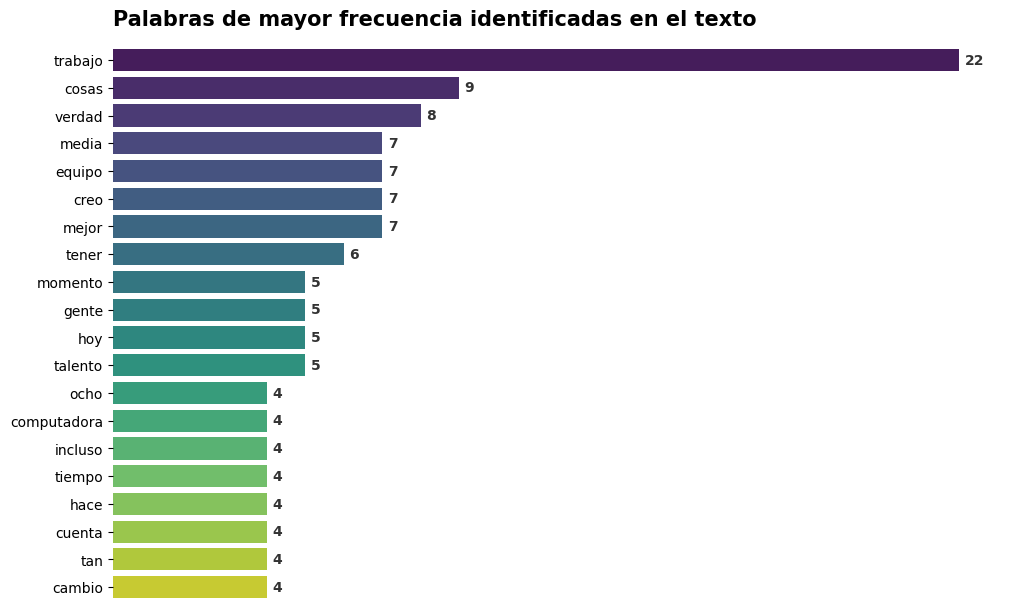


Procesando 2/5: https://www.youtube.com/watch?v=y_meaPeqlB0
[youtube] Extracting URL: https://www.youtube.com/watch?v=y_meaPeqlB0
[youtube] y_meaPeqlB0: Downloading webpage


[youtube] y_meaPeqlB0: Downloading android vr player API JSON
[info] y_meaPeqlB0: Downloading 1 format(s): 251
[download] Destination: corpus\El trabajo remoto es el presente, y su base es la confianza ｜ Damian Schenkelman ｜ TEDxSanIsidro.webm
[download] 100% of    9.76MiB in 00:00:00 at 9.95MiB/s     
[ExtractAudio] Destination: corpus\El trabajo remoto es el presente, y su base es la confianza ｜ Damian Schenkelman ｜ TEDxSanIsidro.mp3
Deleting original file corpus\El trabajo remoto es el presente, y su base es la confianza ｜ Damian Schenkelman ｜ TEDxSanIsidro.webm (pass -k to keep)
Audio descargado: El trabajo remoto es el presente_ y su base es la confianza _ Damian Schenkelman (843 segundos)
Transcripcion completa: 263 segmentos
OK: El trabajo remoto es el presente_ y su base es la confianza _ Damian Schenkelman - 11905 caracteres
--- Resumen con stopwords ---
            Total Palabras      : 2156
            Palabras Únicas     : 623
            Palabra Top         : 'que' (104 ve

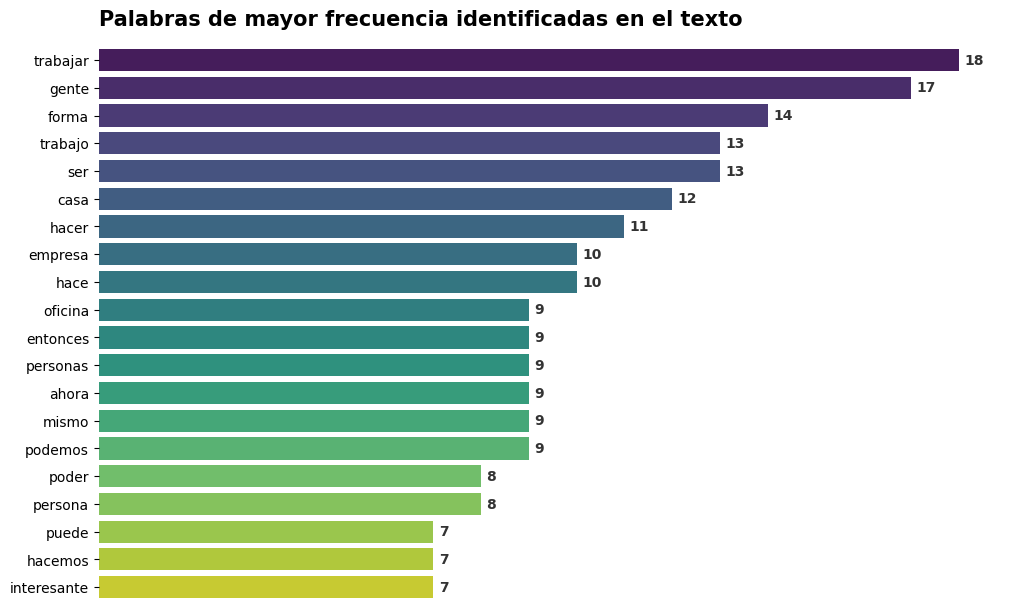


Procesando 3/5: https://www.youtube.com/watch?v=5D-gZ5SUNmI
[youtube] Extracting URL: https://www.youtube.com/watch?v=5D-gZ5SUNmI
[youtube] 5D-gZ5SUNmI: Downloading webpage


[youtube] 5D-gZ5SUNmI: Downloading android vr player API JSON
[info] 5D-gZ5SUNmI: Downloading 1 format(s): 251
[download] Destination: corpus\El Futuro del Trabajo Remoto ｜ Max Faingezicht ｜ TEDxPuraVidaJoven.webm
[download] 100% of   10.62MiB in 00:00:00 at 14.71MiB/s    
[ExtractAudio] Destination: corpus\El Futuro del Trabajo Remoto ｜ Max Faingezicht ｜ TEDxPuraVidaJoven.mp3
Deleting original file corpus\El Futuro del Trabajo Remoto ｜ Max Faingezicht ｜ TEDxPuraVidaJoven.webm (pass -k to keep)
Audio descargado: El Futuro del Trabajo Remoto _ Max Faingezicht _ TEDxPuraVidaJoven (707 segundos)
Transcripcion completa: 116 segmentos
OK: El Futuro del Trabajo Remoto _ Max Faingezicht _ TEDxPuraVidaJoven - 10946 caracteres
--- Resumen con stopwords ---
            Total Palabras      : 1854
            Palabras Únicas     : 675
            Palabra Top         : 'que' (88 veces)
        Frecuencia Promedio : 4.85
--- Resumen sin stopwords ---
            Total Palabras      : 739
           

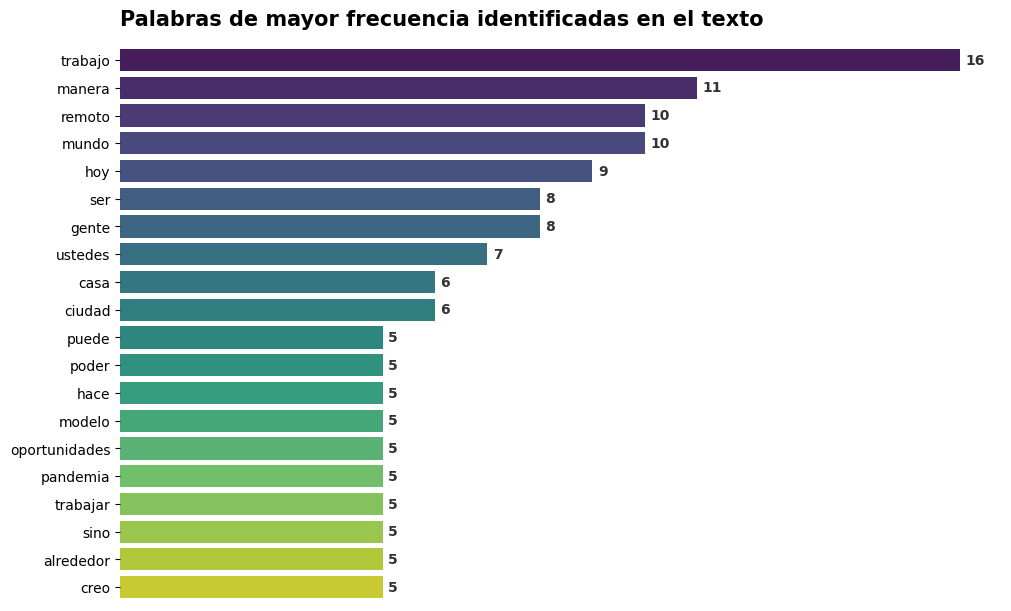


Procesando 4/5: https://www.youtube.com/watch?v=5jI81b19KHs
[youtube] Extracting URL: https://www.youtube.com/watch?v=5jI81b19KHs
[youtube] 5jI81b19KHs: Downloading webpage


[youtube] 5jI81b19KHs: Downloading android vr player API JSON
[info] 5jI81b19KHs: Downloading 1 format(s): 251
[download] Destination: corpus\La Sorprendente verdad sobre el Trabajo Remoto que nadie te cuenta.webm
[download] 100% of    9.96MiB in 00:00:00 at 14.28MiB/s    
[ExtractAudio] Destination: corpus\La Sorprendente verdad sobre el Trabajo Remoto que nadie te cuenta.mp3
Deleting original file corpus\La Sorprendente verdad sobre el Trabajo Remoto que nadie te cuenta.webm (pass -k to keep)
Audio descargado: La Sorprendente verdad sobre el Trabajo Remoto que nadie te cuenta (673 segundos)
Transcripcion completa: 177 segmentos
OK: La Sorprendente verdad sobre el Trabajo Remoto que nadie te cuenta - 11189 caracteres
--- Resumen con stopwords ---
            Total Palabras      : 1852
            Palabras Únicas     : 662
            Palabra Top         : 'de' (100 veces)
        Frecuencia Promedio : 4.95
--- Resumen sin stopwords ---
            Total Palabras      : 770
           

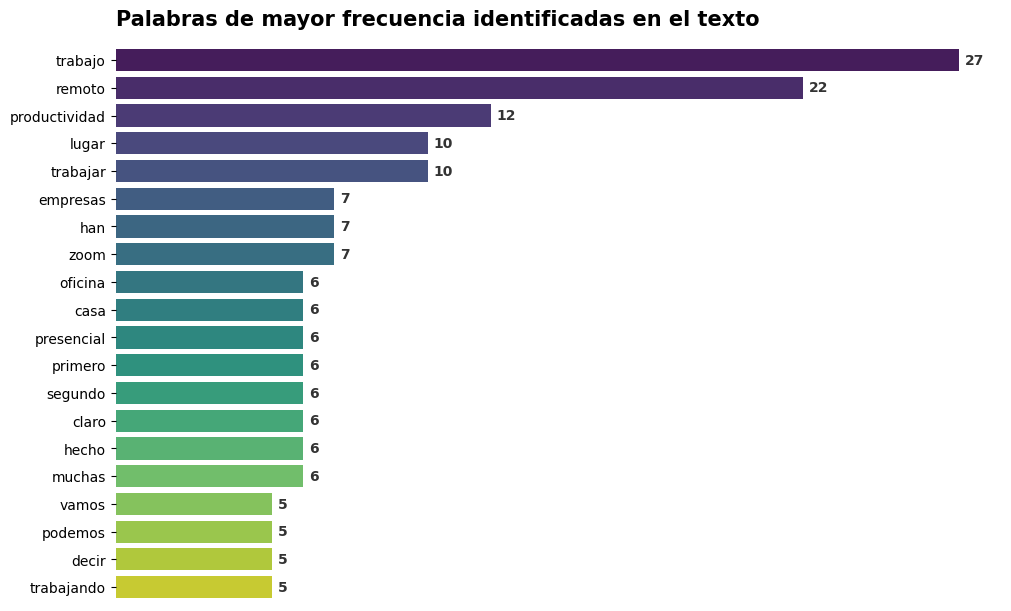


Procesando 5/5: https://www.youtube.com/watch?v=4hv5MIE9b-Y
[youtube] Extracting URL: https://www.youtube.com/watch?v=4hv5MIE9b-Y
[youtube] 4hv5MIE9b-Y: Downloading webpage


[youtube] 4hv5MIE9b-Y: Downloading android vr player API JSON
[info] 4hv5MIE9b-Y: Downloading 1 format(s): 251
[download] Destination: corpus\Por qué hay menos trabajo remoto.webm
[download] 100% of   17.29MiB in 00:00:01 at 16.78MiB/s    
[ExtractAudio] Destination: corpus\Por qué hay menos trabajo remoto.mp3
Deleting original file corpus\Por qué hay menos trabajo remoto.webm (pass -k to keep)
Audio descargado: Por que_ hay menos trabajo remoto (1120 segundos)
Transcripcion completa: 209 segmentos
OK: Por que_ hay menos trabajo remoto - 19904 caracteres
--- Resumen con stopwords ---
            Total Palabras      : 3669
            Palabras Únicas     : 904
            Palabra Top         : 'de' (182 veces)
        Frecuencia Promedio : 4.42
--- Resumen sin stopwords ---
            Total Palabras      : 1397
            Palabras Únicas     : 650
            Palabra Top         : 'trabajo' (30 veces)
        Frecuencia Promedio : 6.58


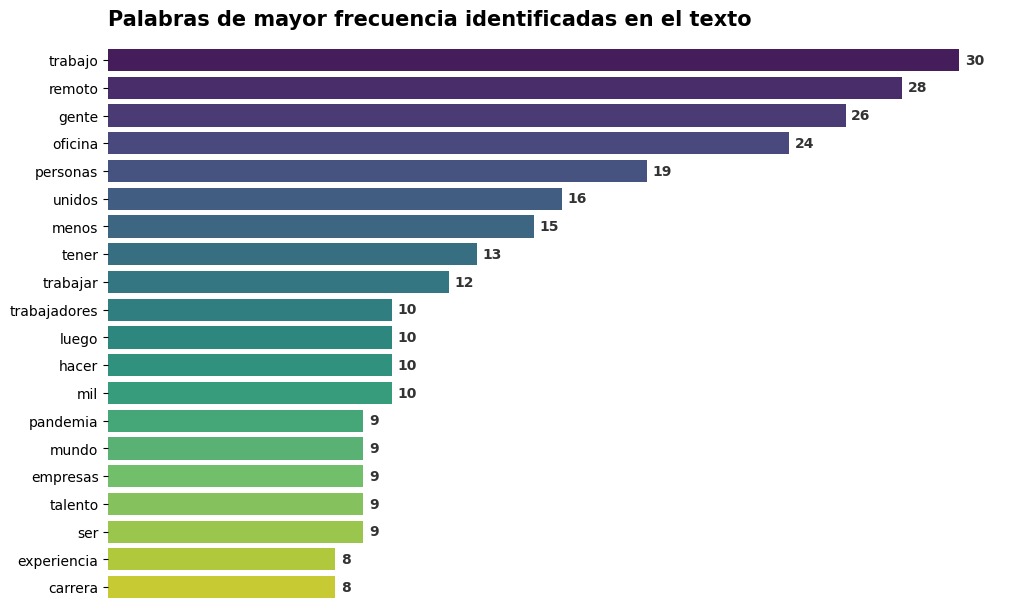


Resumen: 5 exitosos, 0 errores
Corpus total: 62586 caracteres, ~11067 palabras


In [9]:
# https://www.youtube.com/watch?v=9aLCyblgFCA 27/11/2019 9.28 sin subtitulos
# https://www.youtube.com/watch?v=y_meaPeqlB0 06/02/2020 14.02 con subtitulos
# https://www.youtube.com/watch?v=5D-gZ5SUNmI 04/12/2020 11.47 sin subtitulos
# https://www.youtube.com/watch?v=5jI81b19KHs 27/09/2023 11.12 con subtitulos
# https://www.youtube.com/watch?v=4hv5MIE9b-Y 27/09/2025 18.39 sin subtitulos

urls = [
    "https://www.youtube.com/watch?v=9aLCyblgFCA",
    "https://www.youtube.com/watch?v=y_meaPeqlB0",
    "https://www.youtube.com/watch?v=5D-gZ5SUNmI",
    "https://www.youtube.com/watch?v=5jI81b19KHs",
    "https://www.youtube.com/watch?v=4hv5MIE9b-Y"

]

resultados = []
errores = []

for indice, url in enumerate(urls, start=1):
    print("\n" + "=" * 60)
    print(f"Procesando {indice}/{len(urls)}: {url}")
    print("=" * 60)
    try:
        resultado_lote = youtube_a_texto(url, modelo_whisper="small")
        resultados.append(resultado_lote)
        print(f"OK: {resultado_lote['titulo']} - {len(resultado_lote['texto'])} caracteres")
        df = verificar_archivo(resultado_lote['titulo'])
        procesar_corpus(df)

    except Exception as error:
        errores.append({"url": url, "error": str(error)})
        print(f"ERROR: {error}")

print(f"\nResumen: {len(resultados)} exitosos, {len(errores)} errores")

corpus_total = "\n\n---\n\n".join(resultado_lote["texto"] for resultado_lote in resultados)
print(f"Corpus total: {len(corpus_total)} caracteres, ~{len(corpus_total.split())} palabras")


## VIDEO 1
## ¿Y dónde es tu trabajo？ ｜ Guillermo Bracciaforte ｜ TEDxCordoba
**¿Y dónde es tu trabajo?**

**https://www.youtube.com/watch?v=9aLCyblgFCA 27/11/2019 9.28 sin subtitulos**

Nuestro trabajo, ¿es un lugar al que vamos o es aquello que hacemos? A partir de su experiencia personal y los desarrollos realizados por la exitosa plataforma Workana, Guillermo nos propone reflexionar sobre el "trabajo de locación remota" y los cambios que esta tendencia implica para las organizaciones, la sociedad y nuestras propias vidas. Guillermo Bracciaforte es egresado de la UCC y MBA del IAE Business School. Hace 15 años se fue a Buenos Aires, donde trabajó en Google en roles de Operaciones durante cinco años. En 2012 co-fundó Workana, donde tomó el rol de COO. Workana es la primera y mayor red de trabajo remoto e independiente de Latinoamérica. Conecta a más de dos millones de freelancers especializados con empresas que necesitan servicios como desarrollo de aplicaciones web y mobile, diseño y multimedia, redacción, marketing, ventas, etc. Además de su emprendimiento, se dedica a su familia, a andar en bici y a ser un geek sin remedio. This talk was given at a TEDx event using the TED conference format but independently organized by a local community. Learn more at https://www.ted.com/tedx



## VIDEO 2

## El trabajo remoto es el presente, y su base es la confianza ｜ Damian Schenkelman ｜ TEDxSanIsidro

**El trabajo remoto es el presente, y su base es la confianza**

*https://www.youtube.com/watch?v=y_meaPeqlB0 06/02/2020 14.02 con subtitulos*

El trabajo remoto es el presente, y su base es la confianza Damián es Ingen
iero en Informática de la UBA. Tiene más de 10 años de experiencia en la industria, trabajó en empresas como Microsoft y Auth0, y se desempeña en esta última como Director de Ingeniería. En sus ratos libres le gusta pasar tiempo con su familia, amigos, hacer asados, practicar deporte y mirar la NBA. This talk was given at a TEDx event using the TED conference format but independently organized by a local community. Learn more at https://www.ted.com/tedx


## VIDEO 3

## El Futuro del Trabajo Remoto ｜ Max Faingezicht ｜ TEDxPuraVidaJoven

**El Futuro del Trabajo Remoto**

*https://www.youtube.com/watch?v=5D-gZ5SUNmI 04/12/2020 11.47 sin subtitulos*

La pandemia ha acelerado la adopción del trabajo remoto, generando gran oportunidad para las generaciones que crecieron con el mundo digital en su bolsillo. Para muchos el teletrabajo no es nuevo, pero por primera vez compañías grandes y pequeñas alrededor del mundo están dispuestas a reconsiderar el modelo de empleo tradicional. Ven la opción de acceder a un mercado de talento global y de utilizar el trabajo remoto como un agente de cambio cultural y de cómo operan sus equipos. Esto rompe la barrera geográfica que nos limitaba y abre la puerta a oportunidades de trabajo, de crecimiento y de transferencia de conocimiento que antes estaban fuera de nuestro alcance. Pocas veces se ve un cambio de paradigma de esta magnitud y nosotros tenemos la suerte de estar en el lugar correcto y en el momento justo. Está en nosotros como individuos y como nación prepararnos para poder navegar exitosamente esta gigantesca ola." ¿Quién controla tu destino? This talk was given at a TEDx event using the TED conference format but independently organized by a local community. Learn more at https://www.ted.com/tedx

## VIDEO 4

## La Sorprendente verdad sobre el Trabajo Remoto que nadie te cuenta

**La Sorprendente verdad sobre el Trabajo Remoto que nadie te cuenta**

*https://www.youtube.com/watch?v=5jI81b19KHs 27/09/2023 11.12 con subtitulos*
Descubre la verdad sobre el trabajo remoto, presencial e híbrido, y cómo cada uno puede afectar tu productividad y felicidad laboral. En este vídeo, analizamos las ventajas y desventajas de cada modalidad, y te revelamos cómo puedes adaptarte a las nuevas formas de trabajar en la era moderna.


## VIDEO 5

## Por que_ hay menos trabajo remoto

**Por qué hay menos trabajo remoto**

*https://www.youtube.com/watch?v=4hv5MIE9b-Y 27/09/2025 18.39 sin subtitulos*

¿Es el fin del trabajo 100% remoto? Descubre la realidad actual del mundo laboral, donde las empresas están pidiendo a sus equipos que vuelvan a la oficina. 





